# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [2]:
IMAGE_WIDTH=64
IMAGE_HEIGHT=64
IMAGE_CHANNELS=3
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
BATCH_SIZE = 64
EPOCHS = 30

ROOT_PATH = 'C:/Users/urkow/Documents/Documentos_Clase/zz_conv_img/ejercicios/'

TRAIN_PATH = ROOT_PATH+ 'seg_train/'
TEST_PATH = ROOT_PATH + 'seg_test/'


CATEGORIES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [3]:
category_to_id = {cat: i for i, cat in enumerate(CATEGORIES)}

# Lista donde guardaremos los registros
data = []

for category in CATEGORIES:
    folder_path = os.path.join(TRAIN_PATH, category)
    
    for file in os.listdir(folder_path):
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            
            new_filename = f'{category}/{file}'
            
            data.append({
                'filename': new_filename,
                'category': category_to_id[category]
            })

# Convertimos a DataFrame
df = pd.DataFrame(data)

df.head()

,filename,category
0,buildings/0.jpg,0
1,buildings/10006.jpg,0
2,buildings/1001.jpg,0
3,buildings/10014.jpg,0
4,buildings/10018.jpg,0


2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.


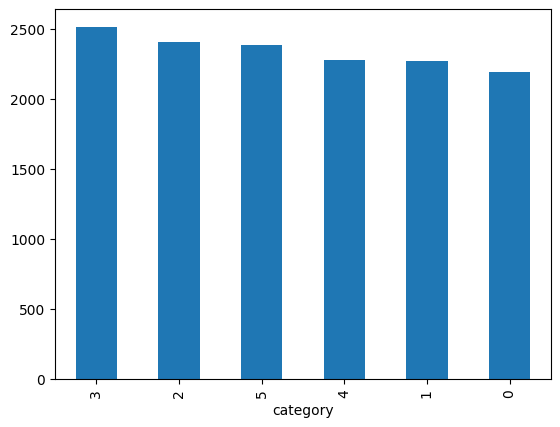

In [4]:
df['category'].value_counts().plot.bar();

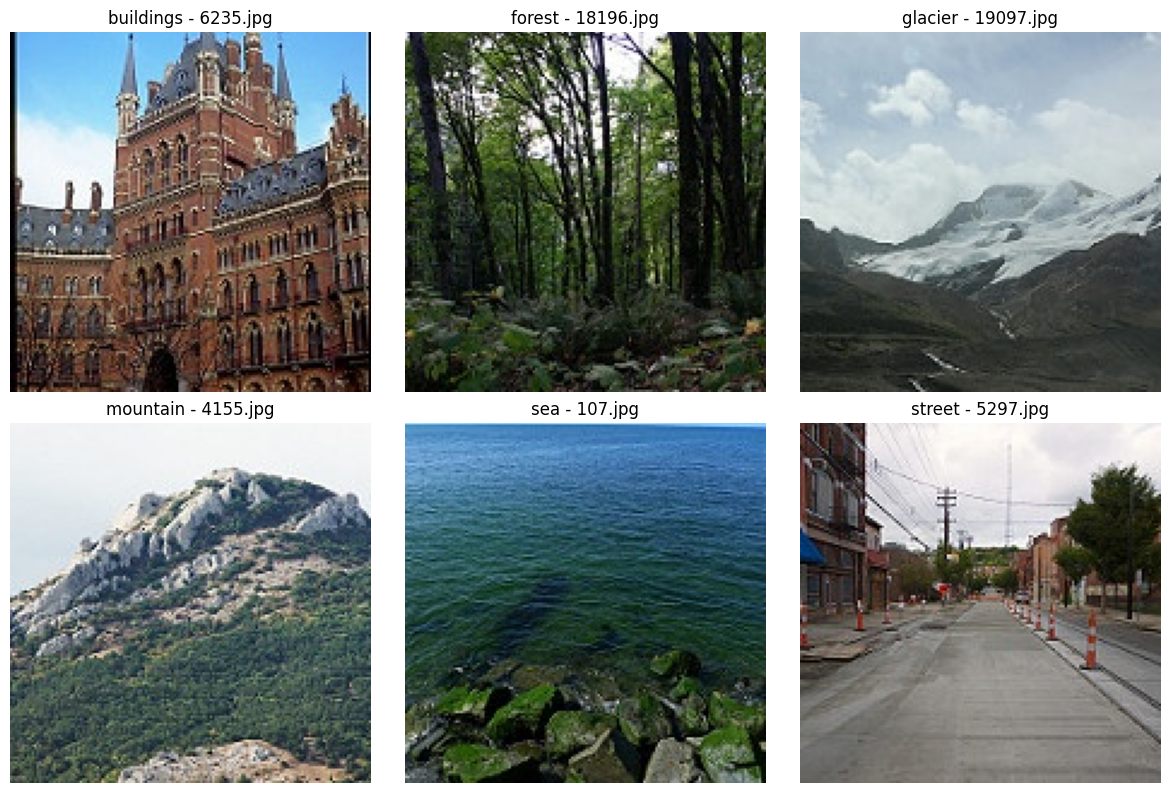

In [5]:
from skimage.io import imread

plt.figure(figsize=(12, 8))

for i, category in enumerate(CATEGORIES):
    
    folder_path = os.path.join(TRAIN_PATH, category)
    
    filenames = [f for f in os.listdir(folder_path)]
    
    sample = random.choice(filenames)
    
    image = imread(os.path.join(folder_path, sample))
    
    # Visualización
    plt.subplot(2, 3, i+1)
    plt.imshow(image)
    plt.title(f"{category} - {sample}")
    plt.axis("off")

plt.tight_layout()
plt.show()

3. Normaliza.

In [6]:
# Función para cargar imágenes
import cv2

def read_data(ruta, df, im_size):
    X = []
    Y = []
    
    for c, cat in enumerate(CATEGORIES):
        path = ruta + cat + '/'
    
        ##### CODE #####
        # Iterar sobre todo lo que haya en path
        for file in os.listdir(path):
            
            # Leer la imagen a color y aplicarle el resize
            image = imread(path + file)
            smallimage = cv2.resize(image, (im_size, im_size))
            
            # Guardo en X
            X.append(smallimage)
            Y.append(c)

    return np.array(X), np.array(Y)

In [7]:
X_train, y_train = read_data(TRAIN_PATH, df, IMAGE_WIDTH)
X_test, y_test = read_data(TEST_PATH, df, IMAGE_WIDTH)

print(X_train.shape)
print(X_test.shape)

(14034, 64, 64, 3)
(3000, 64, 64, 3)


In [8]:
# Buscamos max y min
print("Min:", np.min(X_train))
print("Max:", np.max(X_train))

Min: 0
Max: 255


In [9]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Min:", np.min(X_train))
print("Max:", np.max(X_train))

Min: 0.0
Max: 1.0


4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada.

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [ ]:
from tensorflow import keras


model = keras.Sequential([
    keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=IMAGE_SIZE),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2), # en cada epoch desactivamos un 20% de las neuronas. Así no overfiteamos, ya que no entrenamos la misma neurona con unas características concretas una y otra vez
    keras.layers.Dense(len(CATEGORIES), activation='softmax')  # 6 clases
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 64)        1792      
                                                                 
 max_pooling2d (MaxPooling2  (None, 31, 31, 64)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 128)       73856     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 128)       0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 128)             

5. Reserva un 20% de los datos del entrenamiento para validar.

In [11]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

earlystop = EarlyStopping(patience=10)
mcheckpoint = ModelCheckpoint("callback_model.keras")

In [12]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks = [earlystop, mcheckpoint], 
    validation_split = 0.2)

Epoch 1/30


141/141 [==============================] - 18s 118ms/step - loss: 1.1574 - accuracy: 0.5441 - val_loss: 0.9359 - val_accuracy: 0.6349
Epoch 2/30
141/141 [==============================] - 16s 116ms/step - loss: 0.8317 - accuracy: 0.6892 - val_loss: 0.8015 - val_accuracy: 0.6990
Epoch 3/30
141/141 [==============================] - 16s 113ms/step - loss: 0.6470 - accuracy: 0.7682 - val_loss: 0.7397 - val_accuracy: 0.7355
Epoch 4/30
141/141 [==============================] - 16s 113ms/step - loss: 0.5715 - accuracy: 0.7906 - val_loss: 0.6551 - val_accuracy: 0.7649
Epoch 5/30
141/141 [==============================] - 16s 113ms/step - loss: 0.4432 - accuracy: 0.8459 - val_loss: 0.6338 - val_accuracy: 0.7836
Epoch 6/30
141/141 [==============================] - 16s 112ms/step - loss: 0.3365 - accuracy: 0.8787 - val_loss: 0.6483 - val_accuracy: 0.7907
Epoch 7/30
141/141 [==============================] - 16s 114ms/step - loss: 0.2577 - accuracy: 0.9111 - val_loss: 0.7963 - val_

6. Representa el objeto history.

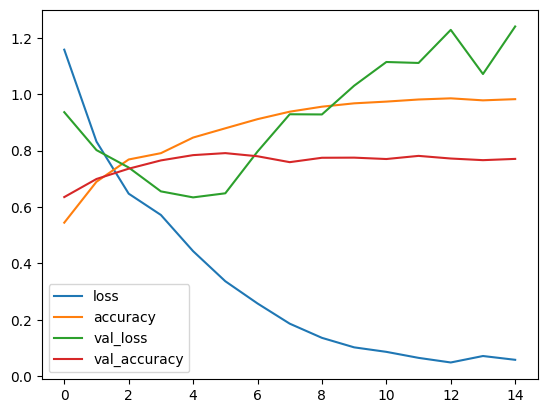

In [13]:
pd.DataFrame(history.history).plot();

7. Evalua el modelo con los datos de test.

In [14]:
loss, acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest accuracy: {acc:.4f}")

94/94 - 2s - loss: 1.1832 - accuracy: 0.7707 - 2s/epoch - 25ms/step

Test accuracy: 0.7707


8. Representa algunos de los paisajes donde el modelo comete errores.

94/94 [==============================] - 3s 25ms/step


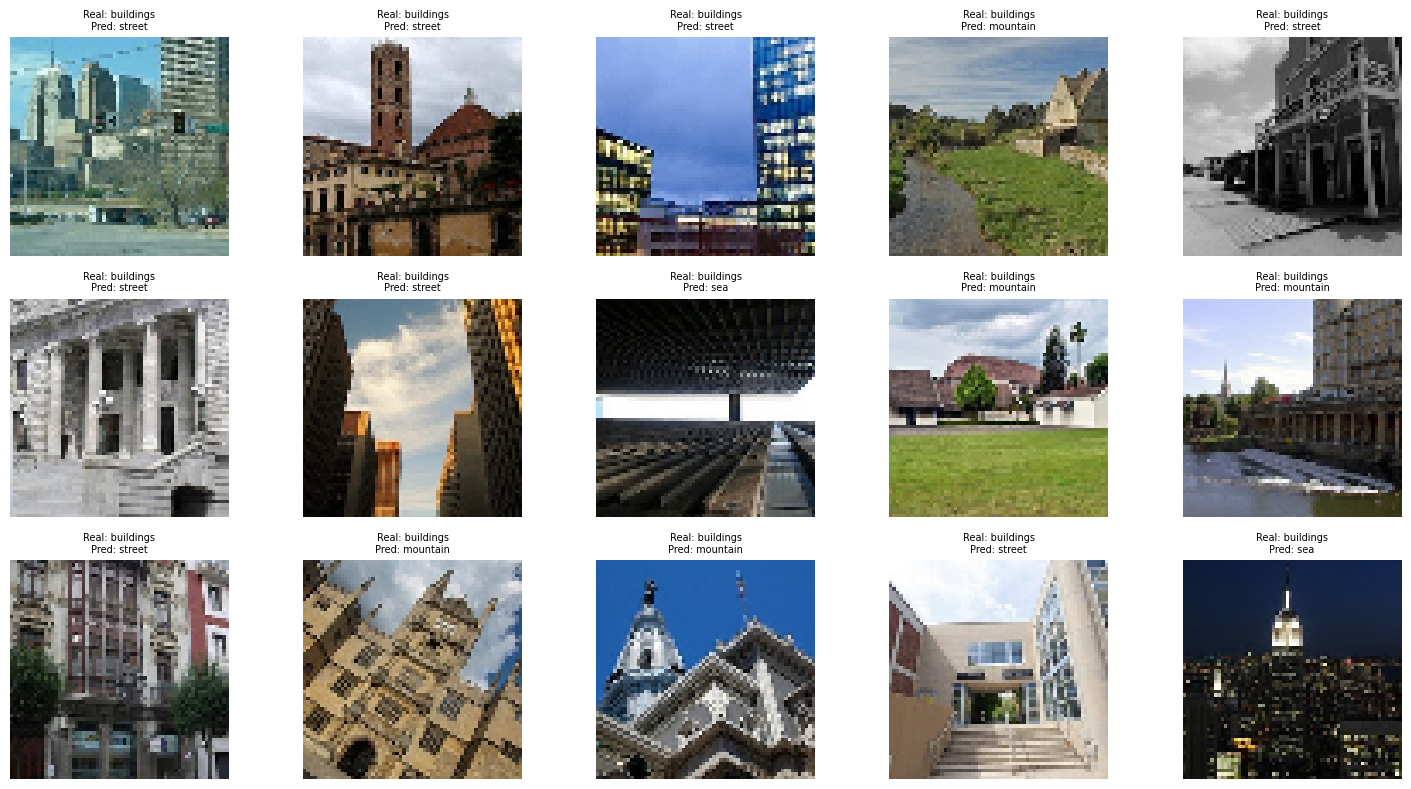

In [15]:
y_pred = np.argmax(model.predict(X_test), axis=1)

# Índices donde falla
error_idx = np.where(y_pred != y_test)[0]

plt.figure(figsize=(15, 8))
for i, idx in enumerate(error_idx[:15]):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.title(f"Real: {CATEGORIES[y_test[idx]]}\nPred: {CATEGORIES[y_pred[idx]]}", fontsize=7)
    plt.axis('off')

plt.tight_layout();

9. Crea una matriz de confusión con los errores del modelo.

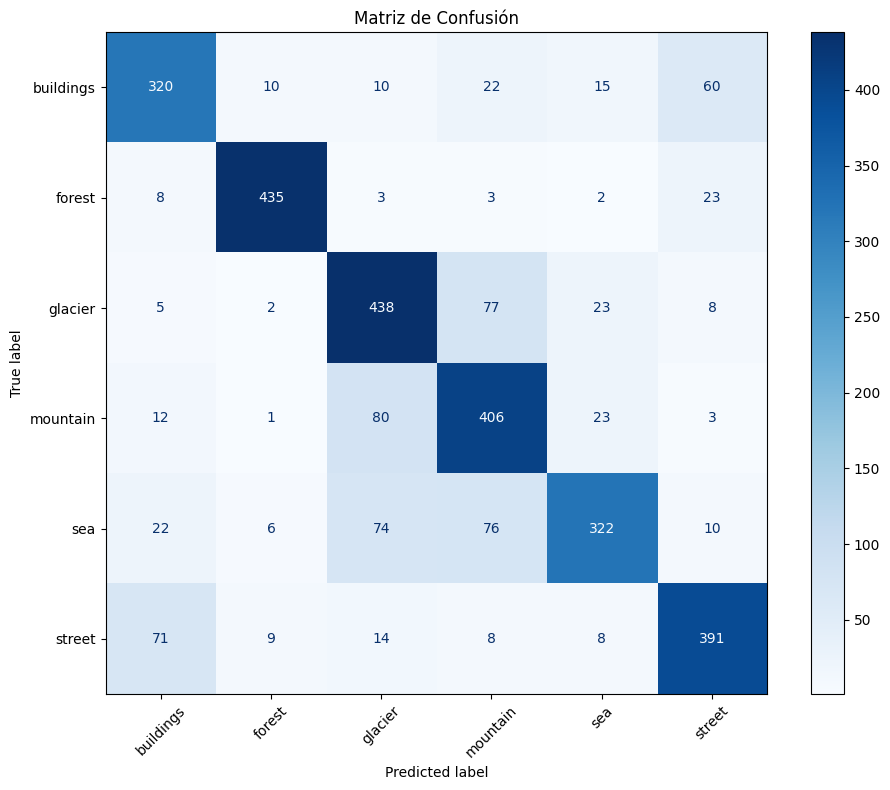

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CATEGORIES)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title('Matriz de Confusión')
plt.tight_layout();